# 线性回归-波士顿房价预测；

本项目使用线性回归模型预测房价。  
数据集使用Boston Housing数据集。

In [1]:
import os;
import numpy as np;
import pandas as pd;
import torch;
import torch.nn as nn;
import torch.optim as optim;
from torch.utils.data import Dataset, DataLoader, TensorDataset;
from sklearn.model_selection import train_test_split;
from sklearn.preprocessing import StandardScaler;
import matplotlib.pyplot as plt;
import warnings;
warnings.filterwarnings('ignore');

In [2]:
DATA_PATH = "./HousingData.csv"; 
TEST_SIZE = 0.2;
RANDOM_SEED = 42;

# 模型相关参数。
INPUT_FEATURES = 13;  # Boston Housing有13个特征。
HIDDEN_SIZE = 128;  # 隐藏层神经元数量。
OUTPUT_SIZE = 1;  # 输出维度：房价中位数。

# 训练相关参数。
BATCH_SIZE = 256;  # 批次大小。
LEARNING_RATE = 0.001;  # 学习率。
EPOCHS = 300;  # 训练轮数。
EARLY_STOPPING_PATIENCE = 30;  # 早停耐心值。

plt.rcParams['font.family'] = 'SimHei'

MODEL_SAVE_PATH = "./house_price_model.pth";  # 模型保存路径。
CONTINUE_TRAIN = 1;  # 是否从已有模型继续训练，设置为True时从MODEL_SAVE_PATH加载模型。


DEVICE = torch.device("cpu");  # 使用CPU训练，因为数据比较少。

## 数据处理：

In [3]:
def load_and_preprocess_data():
    """
    加载并预处理Boston Housing数据集，返回训练集和测试集。
    """
    if os.path.exists(DATA_PATH):
        df = pd.read_csv(DATA_PATH);  # 读取CSV，有表头。
        print(f"✅成功加载Boston Housing数据，共{len(df)}条记录 ！");
        
        # 处理缺失值（NA）。
        na_count = df.isna().sum().sum();
        if na_count > 0:
            print(f"⚠️检测到{na_count}个缺失值，将使用中位数填充 ！");
            df = df.fillna(df.median(numeric_only=True));  # 用中位数填充缺失值。
        
        # Boston Housing特征列名。
        feature_columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'];
        X = df[feature_columns].values;  # 13个特征。
        y = df['MEDV'].values;  # 房价中位数（单位：千美元）。
    else:
        print(f"⚠️数据文件不存在 ！");
        
    # 划分训练集和测试集。
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
    );
    
    # 特征标准化，提升训练稳定性。
    scaler = StandardScaler();
    X_train = scaler.fit_transform(X_train);  # 训练集拟合并转换。
    X_test = scaler.transform(X_test);  # 测试集只转换。
    
    # 保存scaler参数供后续使用。
    global SCALER_MEAN, SCALER_SCALE;
    SCALER_MEAN = scaler.mean_;
    SCALER_SCALE = scaler.scale_;
    
    # 转换为PyTorch张量。
    X_train_tensor = torch.FloatTensor(X_train);
    y_train_tensor = torch.FloatTensor(y_train).view(-1, 1);  # 调整维度为[n,1]。
    X_test_tensor = torch.FloatTensor(X_test);
    y_test_tensor = torch.FloatTensor(y_test).view(-1, 1);
    
    # 创建DataLoader。
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor);
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor);
    
    # 创建DataLoader。
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0  # Windows使用单进程。
    );

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    );
    
    print(f"✅数据预处理完成 ！训练集{len(train_dataset)}条，测试集{len(test_dataset)}条 ！");
    
    return train_loader, test_loader, X_test_tensor, y_test_tensor;

In [4]:
train_loader, test_loader, X_test_tensor, y_test_tensor = load_and_preprocess_data();

✅成功加载Boston Housing数据，共506条记录 ！
⚠️检测到120个缺失值，将使用中位数填充 ！
✅数据预处理完成 ！训练集404条，测试集102条 ！


In [5]:
df = pd.read_csv(DATA_PATH);
    
# 处理缺失值用于预览。
if df.isna().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True));

print(df[:100]);

# 显示特征说明。
print("特征说明（Boston Housing）：");
print("  CRIM - 城镇人均犯罪率。");
print("  ZN - 住宅用地超过25000 sq.ft.的比例。");
print("  INDUS - 城镇非零售业务地区的比例。");
print("  CHAS - 查尔斯河虚拟变量（如果临近河流为1，否则为0）。");
print("  NOX - 一氧化氮浓度（千万分之一）。");
print("  RM - 每个住宅的平均房间数。");
print("  AGE - 1940年之前建成的自住房屋的比例。");
print("  DIS - 到波士顿五个就业中心的加权距离。");
print("  RAD - 径向公路的可达性指数。");
print("  TAX - 每10000美元的全值财产税率。");
print("  PTRATIO - 城镇师生比例。");
print("  B - 1000(Bk - 0.63)^2，其中Bk是城镇黑人比例。");
print("  LSTAT - 人口中地位较低人群的百分数。");
print("  MEDV - 自住房屋的中位数价值（单位：千美元）【标签】。");
print("——"*50);

       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0   0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1   0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2   0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3   0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4   0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   
..      ...   ...    ...   ...    ...    ...   ...     ...  ...  ...      ...   
95  0.12204   0.0   2.89   0.0  0.445  6.625  57.8  3.4952    2  276     18.0   
96  0.11504   0.0   2.89   0.0  0.445  6.163  69.6  3.4952    2  276     18.0   
97  0.12083   0.0   2.89   0.0  0.445  8.069  76.0  3.4952    2  276     18.0   
98  0.08187   0.0   2.89   0.0  0.445  7.820  36.9  3.4952    2  276     18.0   
99  0.06860   0.0   2.89   0.0  0.445  7.416  62.5  3.4952    2  276     18.0   

         B  LSTAT  MEDV  
0

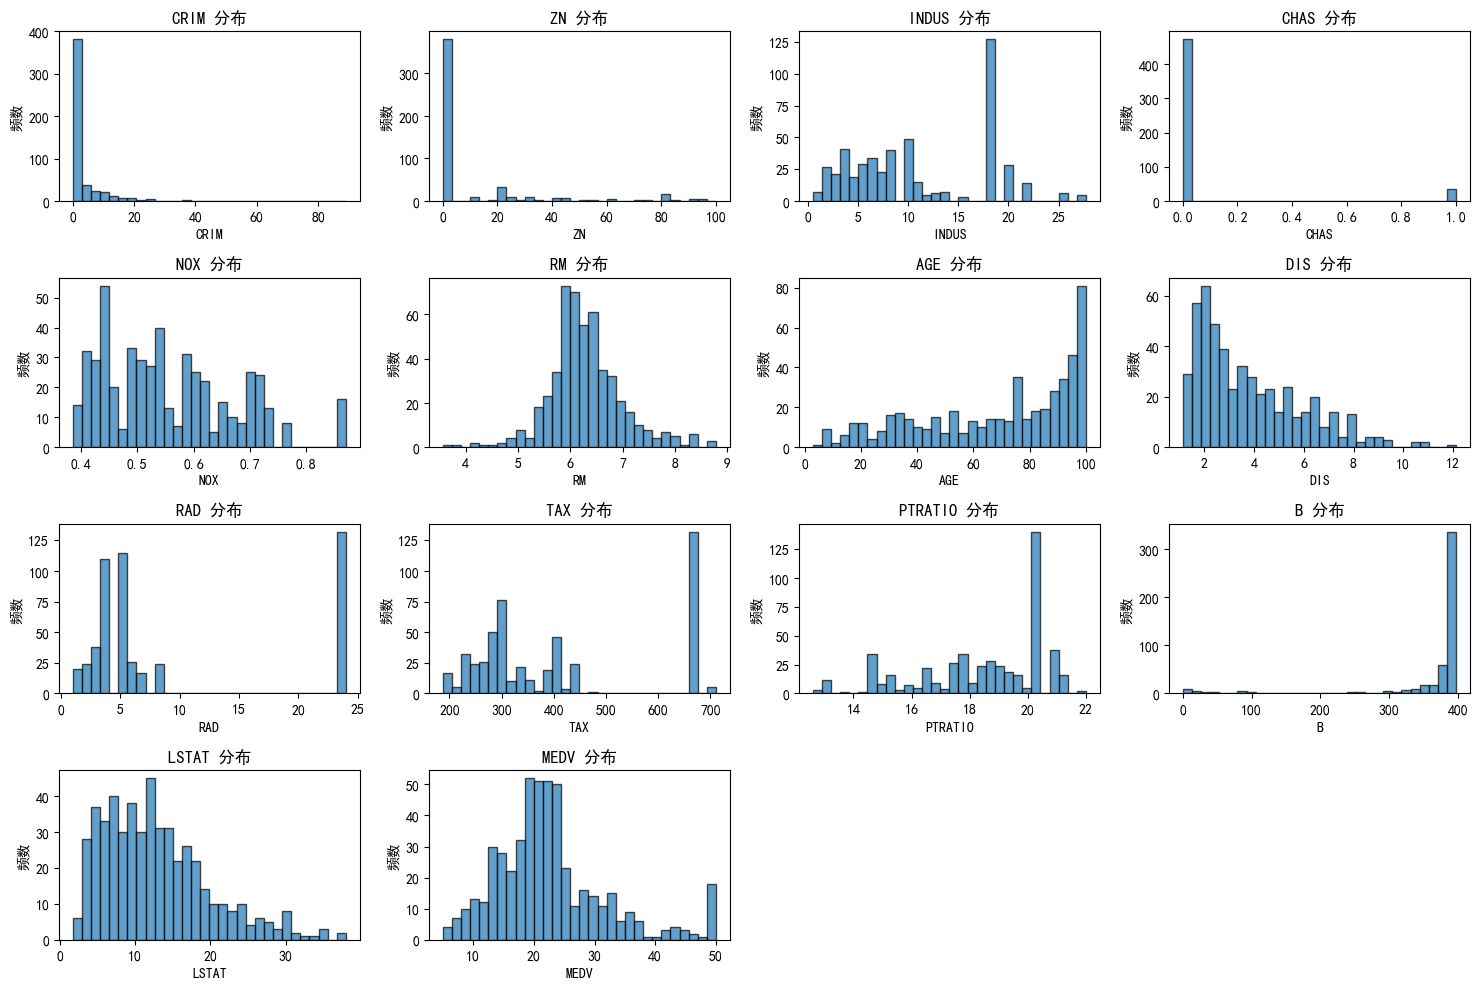

In [6]:
def plot_feature_distribution(df):
    """
    绘制特征分布直方图。
    """
    plt.figure(figsize=(15, 10));
    feature_cols = df.select_dtypes(include=[np.number]).columns;
    n_features = len(feature_cols);
    n_cols = 4;
    n_rows = (n_features + n_cols - 1) // n_cols;

    for i, col in enumerate(feature_cols):
        plt.subplot(n_rows, n_cols, i + 1);
        plt.hist(df[col], bins=30, edgecolor='black', alpha=0.7);
        plt.title(f'{col} 分布');
        plt.xlabel(col);
        plt.ylabel('频数');

    plt.tight_layout();
    plt.show();
plot_feature_distribution(df);

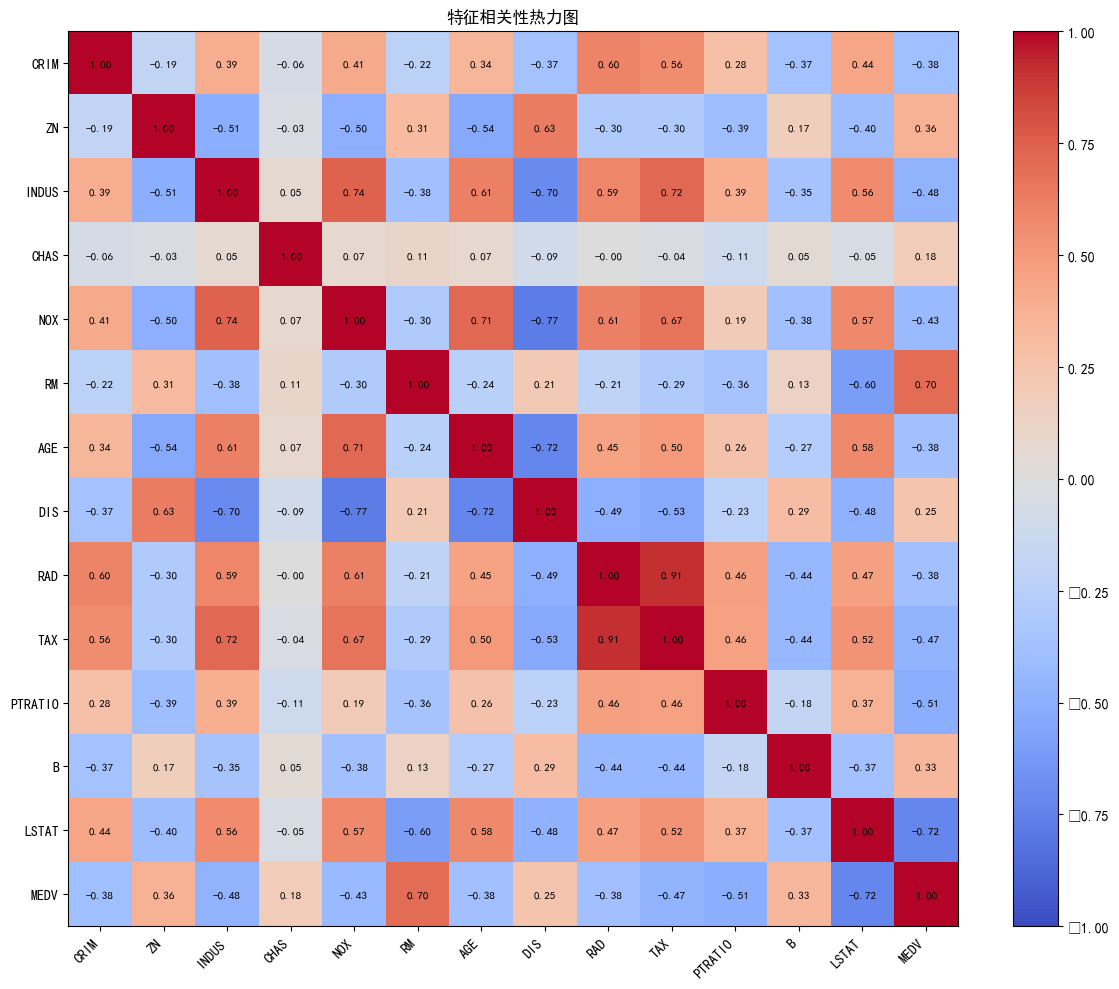

In [7]:
def plot_correlation_heatmap(df):
    """
    绘制特征相关性热力图。
    """
    plt.figure(figsize=(12, 10));
    numeric_df = df.select_dtypes(include=[np.number]);
    corr_matrix = numeric_df.corr();

    im = plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1);
    plt.colorbar(im);

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right');
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns);

    # 添加相关系数文本。
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                     ha='center', va='center', fontsize=8);

    plt.title('特征相关性热力图');
    plt.tight_layout();
    plt.show();
plot_correlation_heatmap(df);

## 模型：

In [8]:
class HousePriceModel(nn.Module):
    """
    房价预测神经网络模型。
    使用多层全连接网络，包含BatchNorm和Dropout提升泛化能力。
    """
    def __init__(self, input_size=13, hidden_size=128, output_size=1):
        super(HousePriceModel, self).__init__();
        
        # 第一层全连接。
        self.fc1 = nn.Linear(input_size, hidden_size);
        self.bn1 = nn.BatchNorm1d(hidden_size);  # 批归一化加速收敛。
        self.relu1 = nn.ReLU();  # ReLU激活函数。
        self.dropout1 = nn.Dropout(0.2);  # Dropout防止过拟合。
        
        # 第二层全连接。
        self.fc2 = nn.Linear(hidden_size, hidden_size//2);
        self.bn2 = nn.BatchNorm1d(hidden_size//2);
        self.relu2 = nn.ReLU();
        self.dropout2 = nn.Dropout(0.2);
        
        # 第三层全连接，增加模型容量处理更多特征。
        self.fc3 = nn.Linear(hidden_size//2, hidden_size//4);
        self.bn3 = nn.BatchNorm1d(hidden_size//4);
        self.relu3 = nn.ReLU();
        self.dropout3 = nn.Dropout(0.2);
        
        # 输出层。
        self.fc4 = nn.Linear(hidden_size//4, output_size);
        
    def forward(self, x):
        """前向传播。"""
        x = self.fc1(x);
        x = self.bn1(x);
        x = self.relu1(x);
        x = self.dropout1(x);
        
        x = self.fc2(x);
        x = self.bn2(x);
        x = self.relu2(x);
        x = self.dropout2(x);
        
        x = self.fc3(x);
        x = self.bn3(x);
        x = self.relu3(x);
        x = self.dropout3(x);
        
        x = self.fc4(x);  # 输出层不加激活，回归问题直接输出数值。
        return x;

def build_model():
    """
    构建模型。
    """
    model = HousePriceModel(INPUT_FEATURES, HIDDEN_SIZE, OUTPUT_SIZE);

    # 如果是继续训练模式，加载已有模型权重。
    if CONTINUE_TRAIN and os.path.exists(MODEL_SAVE_PATH):
        model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE));
        print(f"✅已从{MODEL_SAVE_PATH}加载模型，继续训练 ！");

    return model;

In [9]:
# 构建模型。
model = build_model();
print(f"✅模型构建完成，参数量: {sum(p.numel() for p in model.parameters())} ！");

✅已从./house_price_model.pth加载模型，继续训练 ！
✅模型构建完成，参数量: 12609 ！


## 训练：

In [10]:
def train_model(model, train_loader, test_loader):
    """
    训练模型，支持早停和最佳模型保存。
    """
    criterion = nn.MSELoss();  # 均方误差损失，适合回归问题。
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5);  # Adam优化器。
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, verbose=True
    );  # 学习率衰减策略。
    
    # 早停相关变量。
    best_loss = float('inf');  # 最佳验证损失。
    patience_counter = 0;  # 早停计数器。
    
    # 记录损失用于绘图。
    train_losses = [];
    val_losses = [];
    
    print("——"*50);
    print("🚀 开始训练 ！");
    print("——"*50);
    
    # 训练循环。
    for epoch in range(EPOCHS):
        model.train();  # 切换到训练模式。
        train_loss = 0.0;  # 累计训练损失。
        
        # 遍历训练数据。
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad();  # 梯度清零。
            output = model(data);  # 前向传播。
            loss = criterion(output, target);  # 计算损失。
            loss.backward();  # 反向传播。
            optimizer.step();  # 更新参数。

            train_loss += loss.item();  # 累加损失。
        
        # 计算平均训练损失。
        avg_train_loss = train_loss / len(train_loader);
        train_losses.append(avg_train_loss);
        
        # 验证阶段。
        model.eval();  # 切换到评估模式。
        val_loss = 0.0;  # 累计验证损失。
        
        with torch.no_grad():  # 验证时不计算梯度，节省内存。
            for data, target in test_loader:
                output = model(data);
                loss = criterion(output, target);
                val_loss += loss.item();
        
        avg_val_loss = val_loss / len(test_loader);  # 平均验证损失。
        val_losses.append(avg_val_loss);
        
        # 学习率调整。
        scheduler.step(avg_val_loss);
        
        # 每10轮输出一次训练信息。
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] - 训练损失: {avg_train_loss:.4f}, 验证损失: {avg_val_loss:.4f} ！");
        
        # 保存最佳模型。
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss;
            patience_counter = 0;  # 重置早停计数器。
            torch.save(model.state_dict(), MODEL_SAVE_PATH);  # 保存模型。
        else:
            patience_counter += 1;  # 早停计数器加1。
        
        # 早停判断。
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"⏹️早停触发，连续{EARLY_STOPPING_PATIENCE}轮验证损失未下降 ！");
            break;
    
    print("✅训练完成 ！最佳验证损失: {:.4f} ！".format(best_loss));
    print(f"💾最佳模型已保存至: {MODEL_SAVE_PATH} ！");
    
    return model, train_losses, val_losses;

In [11]:
# 训练模型。
model, train_losses, val_losses = train_model(model, train_loader, test_loader);

————————————————————————————————————————————————————————————————————————————————————————————————————
🚀 开始训练 ！
————————————————————————————————————————————————————————————————————————————————————————————————————
Epoch [1/300] - 训练损失: 12.4834, 验证损失: 12.0781 ！
Epoch [10/300] - 训练损失: 14.0007, 验证损失: 13.0265 ！
Epoch [20/300] - 训练损失: 11.1946, 验证损失: 13.1447 ！
Epoch [30/300] - 训练损失: 12.3275, 验证损失: 12.4337 ！
⏹️早停触发，连续30轮验证损失未下降 ！
✅训练完成 ！最佳验证损失: 12.0781 ！
💾最佳模型已保存至: ./house_price_model.pth ！


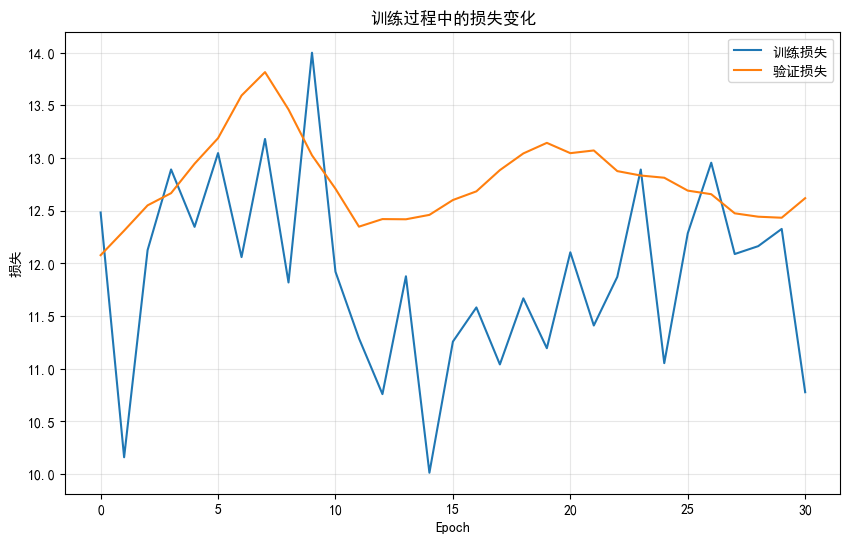

In [12]:
plt.figure(figsize=(10, 6));
plt.plot(train_losses, label='训练损失');
plt.plot(val_losses, label='验证损失');
plt.xlabel('Epoch');
plt.ylabel('损失');
plt.title('训练过程中的损失变化');
plt.legend();
plt.grid(True, alpha=0.3);
plt.show();

In [13]:
def evaluate_model(model, X_test, y_test):
    """
    评估模型性能，输出各项指标并生成可视化图表。
    """
    model.eval();

    with torch.no_grad():
        y_pred = model(X_test).numpy();  # 预测结果。
        y_true = y_test.numpy();

    # 计算评估指标。
    mse = np.mean((y_pred - y_true) ** 2);  # 均方误差。
    rmse = np.sqrt(mse);  # 均方根误差。
    mae = np.mean(np.abs(y_pred - y_true));  # 平均绝对误差。
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2);  # R²分数。

    print("——"*50);
    print("📊 模型评估结果 ！");
    print("——"*50);
    print(f"MSE (均方误差): {mse:.4f} ！");
    print(f"RMSE (均方根误差): {rmse:.4f} ！");
    print(f"MAE (平均绝对误差): {mae:.4f} ！");
    print(f"R² 分数: {r2:.4f} ！");
    print("——"*50);

    # 输出部分预测对比。
    print("预测结果对比（前10条）：");
    print("真实值\t\t预测值\t\t误差");
    for i in range(min(10, len(y_true))):
        error = abs(y_true[i][0] - y_pred[i][0]);
        print(f"{y_true[i][0]:.2f}\t\t{y_pred[i][0]:.2f}\t\t{error:.2f} ！");
    print("——"*50);

    return y_true, y_pred, mse, rmse, mae, r2;

In [14]:
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE));

# 评估模型效果。
y_true, y_pred, mse, rmse, mae, r2 = evaluate_model(model, X_test_tensor, y_test_tensor);

————————————————————————————————————————————————————————————————————————————————————————————————————
📊 模型评估结果 ！
————————————————————————————————————————————————————————————————————————————————————————————————————
MSE (均方误差): 12.0781 ！
RMSE (均方根误差): 3.4754 ！
MAE (平均绝对误差): 2.0245 ！
R² 分数: 0.8353 ！
————————————————————————————————————————————————————————————————————————————————————————————————————
预测结果对比（前10条）：
真实值		预测值		误差
23.60		26.56		2.96 ！
32.40		34.67		2.27 ！
13.60		14.55		0.95 ！
22.80		23.02		0.22 ！
16.10		15.17		0.93 ！
20.00		21.44		1.44 ！
17.80		17.91		0.11 ！
14.00		12.72		1.28 ！
19.60		21.94		2.34 ！
16.80		19.30		2.50 ！
————————————————————————————————————————————————————————————————————————————————————————————————————


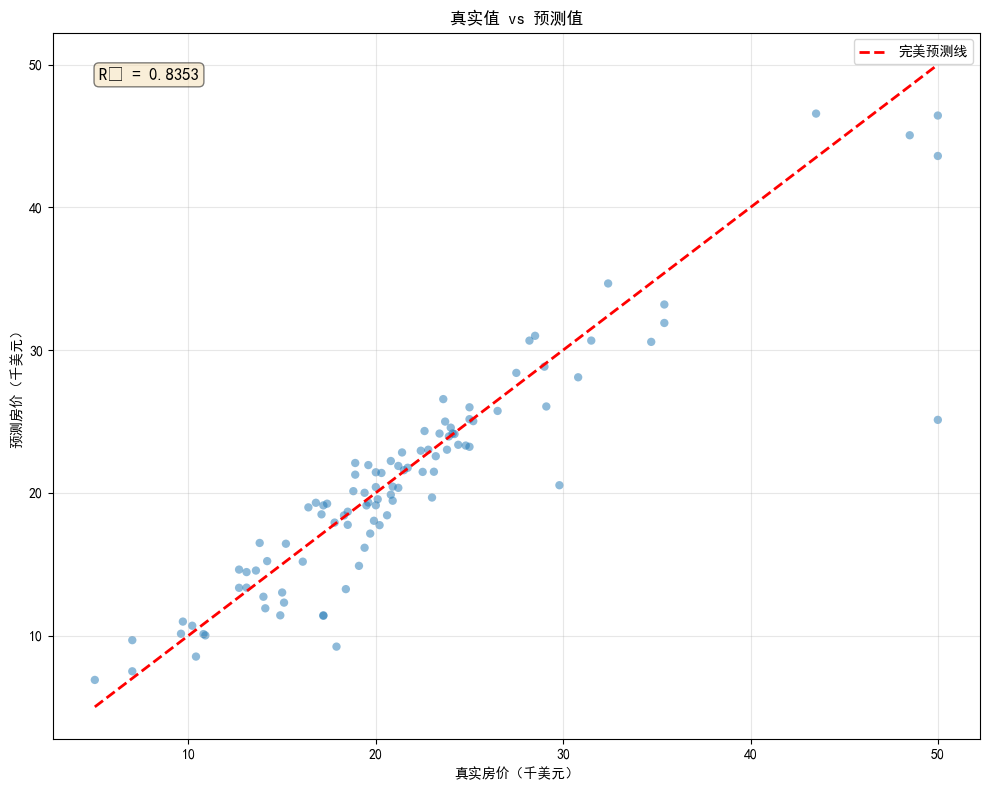

In [15]:
def plot_predictions(y_true, y_pred):
    """
    绘制真实值vs预测值散点图。
    """
    plt.figure(figsize=(10, 8));

    # 散点图。
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolors='none');

    # 对角线（完美预测线）。
    min_val = min(y_true.min(), y_pred.min());
    max_val = max(y_true.max(), y_pred.max());
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='完美预测线');

    plt.xlabel('真实房价（千美元）');
    plt.ylabel('预测房价（千美元）');
    plt.title('真实值 vs 预测值');
    plt.legend();
    plt.grid(True, alpha=0.3);

    # 添加R²分数。
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2);
    plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5));

    plt.tight_layout();
    plt.show();

plot_predictions(y_true.flatten(), y_pred.flatten());

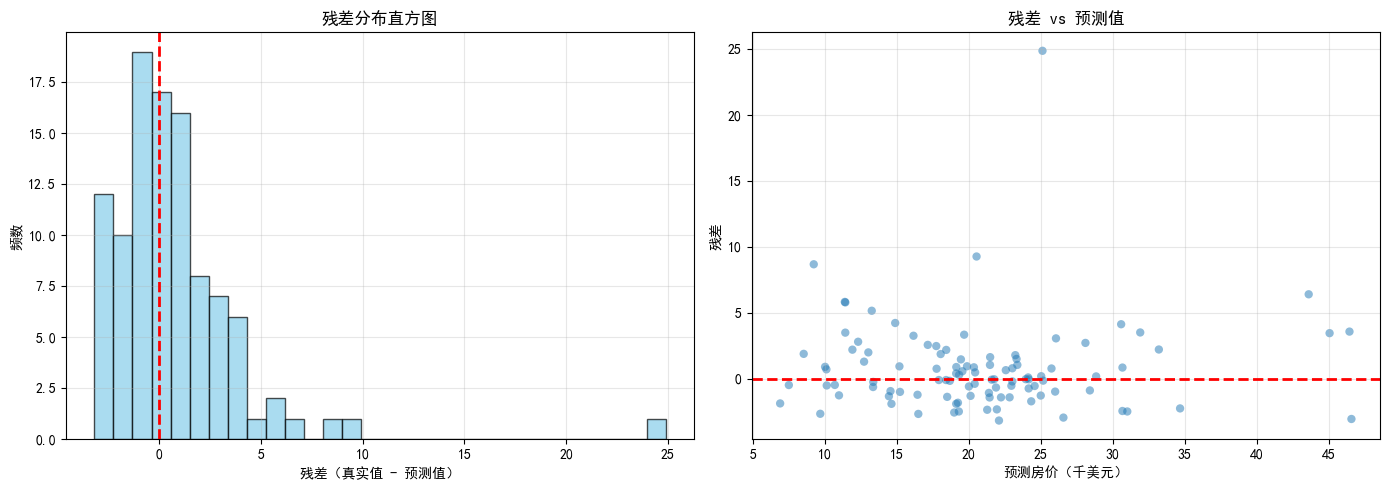

In [16]:
def plot_residuals(y_true, y_pred):
    """
    绘制残差分布图。
    """
    residuals = y_true - y_pred;

    fig, axes = plt.subplots(1, 2, figsize=(14, 5));

    # 残差直方图。
    axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue');
    axes[0].axvline(x=0, color='r', linestyle='--', lw=2);
    axes[0].set_xlabel('残差（真实值 - 预测值）');
    axes[0].set_ylabel('频数');
    axes[0].set_title('残差分布直方图');
    axes[0].grid(True, alpha=0.3);

    # 残差vs预测值散点图。
    axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='none');
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2);
    axes[1].set_xlabel('预测房价（千美元）');
    axes[1].set_ylabel('残差');
    axes[1].set_title('残差 vs 预测值');
    axes[1].grid(True, alpha=0.3);

    plt.tight_layout();
    plt.show();

plot_residuals(y_true.flatten(), y_pred.flatten());

## 单条预测演示：

In [17]:
def predict_single(model, crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat):
    """
    对单条Boston Housing数据进行房价预测。
    参数说明：犯罪率、住宅用地比例、非零售业务比例、查尔斯河变量、一氧化氮浓度、
             平均房间数、老房比例、就业中心距离、公路可达性指数、财产税率、
             师生比例、黑人比例指数、低收入人群比例。
    """
    model.eval();

    # 标准化输入。
    input_data = np.array([[crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat]]);
    input_scaled = (input_data - SCALER_MEAN) / SCALER_SCALE;
    input_tensor = torch.FloatTensor(input_scaled);

    with torch.no_grad():
        prediction = model(input_tensor).item();

    return prediction;

In [18]:
print("——"*50);
print("🔮 单条预测演示 ！");
print("——"*50);

# Boston Housing格式的示例数据。
sample_houses = [
    (0.00632, 18.0, 2.31, 0, 0.538, 6.575, 65.2, 4.09, 1, 296, 15.3, 396.9, 4.98),   # 高房价区域。
    (0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.967, 2, 242, 17.8, 396.9, 9.14),  # 中等房价。
    (0.21124, 12.5, 7.87, 0, 0.524, 5.631, 100.0, 6.082, 5, 311, 15.2, 386.63, 29.93),  # 低房价区域。
];

for i, house in enumerate(sample_houses):
    price = predict_single(model, *house);
    print(f"样本{i+1}: 房间数{house[5]:.2f}, 低收入比例{house[12]:.1f}% -> 预测房价中位数: {price:.2f}千美元 ！");

————————————————————————————————————————————————————————————————————————————————————————————————————
🔮 单条预测演示 ！
————————————————————————————————————————————————————————————————————————————————————————————————————
样本1: 房间数6.58, 低收入比例5.0% -> 预测房价中位数: 24.56千美元 ！
样本2: 房间数6.42, 低收入比例9.1% -> 预测房价中位数: 23.01千美元 ！
样本3: 房间数5.63, 低收入比例29.9% -> 预测房价中位数: 16.27千美元 ！
